In [1]:
library(Seurat)
#library(SeuratData)
library(patchwork)
library(tidyverse)
library(clusterProfiler)
library(org.Hs.eg.db)
library(ggstance)
library(DESeq2)
library(SingleCellExperiment)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘patchwork’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”
Warning message:
“package ‘lubridate’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   3.5.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘clusterProfiler’ was built under R version 4.3.2”


cluster

In [2]:
GCA_data <- readRDS('GCA_obj_subset_excludecells3.Rdata')

In [3]:
GCA_data@meta.data$subcelltype  %>% unique()

[1] Tcells       Endothelial  Plasma       MyeloidCells Bcell       
 [6] Musclecell   Epi_tumor    Mastcell     Fibroblasts  Pericyte    
[11] Epi_normal  
11 Levels: Tcells Endothelial Plasma MyeloidCells Bcell ... Pericyte

In [4]:
GCA_data@meta.data  %>%  filter(subcelltype=='MyeloidCells')%>% 
        rownames()  %>%  GCA_data[,.] -> GCA_obj_subset_Epi

In [5]:
GCA_data@meta.data$celltype  %>% unique()

[1] "CD4+ T"         "Endothelial"    "Plasma"         "Regulatory T"  
 [5] "NKcell"         "Neutrophils"    "Bcell"          "CD8+ Low"      
 [9] "MacrophageM2"   "Musclecell"     "Epi_tumor"      "Monocytes"     
[13] "CD8+ T"         "MacrophageM1"   "Mastcell"       "DendriticCells"
[17] "Fibroblasts"    "Pericyte"       "Epi_normal"

In [6]:
GCA_data@meta.data  %>% dplyr::count(sample)

sample,n
<chr>,<int>
SC005,5803
SC008,3763
SC015,6762
SC017,6765
SC027,13694
SC031,5343
SC032,4782


### read the coding gene

In [7]:
procoding <- read.table('/disk1/pengweixing/database/hg38/hg38.v29.procod.gene.pos',header=F)

In [8]:
genes <- procoding$V4

### load the erbb2 group

In [9]:
lownames <- readRDS(file = "lownames.rds")
highnames <- readRDS(file = "highnames.rds")

In [10]:
GCA_obj_subset_Epi@meta.data  %>%  mutate(group=ifelse(sample %in% lownames,'low','high')) -> GCA_obj_subset_Epi@meta.data 

In [11]:
GCA_obj_subset_Epi@meta.data  %>% dplyr::count(group)

group,n
<chr>,<int>
high,1374
low,3138


### downsample

In [12]:
highindex <- sample(1:3138, size = 1374, replace = FALSE)

In [13]:
high_downnames <- GCA_obj_subset_Epi@meta.data  %>% filter(group=='low')  %>% .[highindex,] %>% rownames()

In [14]:
low_downnames <- GCA_obj_subset_Epi@meta.data  %>% filter(group=='high')   %>%  rownames()

In [15]:
GCA_obj_subset_Epi_down <- GCA_obj_subset_Epi[,c(high_downnames,low_downnames)]

In [16]:
GCA_obj_subset_Epi_down@meta.data  %>%  dplyr::count(group)

group,n
<chr>,<int>
high,1374
low,1374


### renormalize

In [17]:
GCA_obj_subset_Epi_down[["RNA"]] <- split(GCA_obj_subset_Epi_down[["RNA"]],
                                           f = GCA_obj_subset_Epi_down$sample)

Splitting ‘counts’, ‘data’ layers. Not splitting ‘scale.data’. If you would like to split other layers, set in `layers` argument.



In [18]:
GCA_obj_subset_Epi_down <- NormalizeData(GCA_obj_subset_Epi_down)

Normalizing layer: counts.SC005

Normalizing layer: counts.SC008

Normalizing layer: counts.SC015

Normalizing layer: counts.SC017

Normalizing layer: counts.SC027

Normalizing layer: counts.SC031

Normalizing layer: counts.SC032



In [19]:
all.genes <- rownames(GCA_obj_subset_Epi_down)
GCA_obj_subset_Epi_down <- ScaleData(GCA_obj_subset_Epi_down, features = all.genes)

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”


In [20]:
# re-join layers after integration
GCA_obj_subset_Epi_down[["RNA"]] <- JoinLayers(GCA_obj_subset_Epi_down[["RNA"]])

In [21]:
GCA_obj_subset_Epi_down

An object of class Seurat 
36601 features across 2748 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, integrated.cca, umap

### find markers

In [22]:
Idents(GCA_obj_subset_Epi_down) <- 'group'

In [23]:
low.vs.high.markers <- FindMarkers(GCA_obj_subset_Epi_down, ident.1 = 'high', ident.2 = 'low'  ,slot = "scale.data",
                                   logfc.threshold = 0,  min.cells.feature = 1,  min.pct = 0.01,min.cells.group = 0)

In [24]:
low.vs.high.markers  %>% openxlsx::write.xlsx( file = "Myeloid_differential.xlsx",rowNames=TRUE)

In [25]:
low.vs.high.markers['CD47',]

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CD47,1.65263e-13,-1.306186,0.329,0.4,6.04879e-09


In [26]:
dim(low.vs.high.markers)

[1] 14016     5

In [27]:
low.vs.high.markers  %>% rownames()  %>% intersect(genes)  %>% low.vs.high.markers[.,] -> low.vs.high.markers_coding

In [28]:
low.vs.high.markers  %>% mutate(group = ifelse(avg_log2FC>0,'High','Low')) -> low.vs.high.markers

In [9]:
Sti_immunecheckpoint <- c("CD27","CD70",## stimulatory, T cell receptor, APC ligand
                      "CD28","CD80","CD86",## stimulatory, CD4+ T cell receptor, APC ligand *2       
                      "CD40","CD40LG",## stimulatory,  CD4+ T cell ligand,APC cell receptor
                  #    "IL2RB","IL2",## stimulatory, receptor, CD4+ Tcell ligand
                 #     "TNFRSF9","CDC37L1",## stimulatory, Tcell receptor, APC ligand
                      "TNFRSF4","TNFSF4",## stimulatory, (OX40:OX40L) Tregs Receptor, APC ligand
                      "TNFRSF18","TNFSF18"## stimulatory (aka,GITR), CD8+ T cell Receptor, APC ligand 
                  #    "ICOS","ICOSLG",## stimulatory, CD4+ T cell Receptor, APC ligand
                 #     "CD276", ## No receptory, APC ligand
                 #     "TMIGD2","HHLA2"### Receptor , APC 
                         )
Inh_immunecheckpoint <- c("CTLA4",#"CD80","CD86",## Inhibitory,Tregs receptor, APC ligand *2
                   #   "ADORA2A","ADORA2B",##Inhibitory , Tcell receptor, ligand: adenosine
                      "BTLA","TNFRSF14", ##Inhibitory, aka TNFRSF14 HVEM, Tcell receptor, APC ligand
                   #   "IDO1", ###Inhibitory, NA ,APC enzyme
                      "LAG3","FGL1", ###Inhibitory, Tcell receptor,APC ligand.
                   #   "CYBB", ##Inhibitory enzyme
                      "PDCD1","CD274","PDCD1LG2",##Inhibitory Tcell receptor, APC ligand
               #       "HAVCR2","HMGB1","LGALS9",##aka,TIM-3,Inhibitory, Tcell receptor, APC ligand *3
                #      "VSIR","IGSF11",##Inhibitory, Tcell receptor, APC ligand
                   #   "SIGLEC7",##Inhibitory, Tcell receptor , ligand: sugar
                      "TIGIT","PVR",##Inhibitory, Tcell ligand, APC recetpor
                      "SIRPA","CD47" ##Inhibitory, immune ligand, APC recetpor
                      )

In [10]:
low.vs.high.markers[c(Sti_immunecheckpoint,Inh_immunecheckpoint),] -> immunecheckpoint_diff

In [11]:
immunecheckpoint_diff

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,group
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CD27,5.742314e-02,2.6672881,0.025,0.004,1.000000e+00,High
CD70,8.102872e-02,1.3763804,0.037,0.012,1.000000e+00,High
CD28,7.751036e-01,-0.5854879,0.025,0.021,1.000000e+00,Low
CD80,8.014310e-07,0.4399263,0.315,0.108,2.933318e-02,High
CD86,6.293258e-05,0.4069091,0.676,0.448,1.000000e+00,High
CD40,1.415446e-10,0.5361769,0.394,0.112,5.180675e-06,High
NA,NA,NA,NA,NA,NA,NA
TNFRSF4,9.792447e-03,-0.1388825,0.100,0.037,1.000000e+00,Low
NA.1,NA,NA,NA,NA,NA,NA


In [32]:
openxlsx::write.xlsx(immunecheckpoint_diff, file = "Myeloid_immunegenes_differential.HvsL.xlsx",
                     rowNames=TRUE)

In [40]:
rownames(immunecheckpoint_diff) -> cleaned_vector

In [41]:
cleaned_vector <- cleaned_vector[!grepl("^NA", cleaned_vector)]

In [42]:
cleaned_vector

[1] "CD27"     "CD70"     "CD28"     "CD80"     "CD86"     "CD40"    
 [7] "TNFRSF4"  "TNFRSF18" "TNFSF18"  "CTLA4"    "BTLA"     "TNFRSF14"
[13] "LAG3"     "PDCD1"    "CD274"    "PDCD1LG2" "TIGIT"    "PVR"     
[19] "SIRPA"    "CD47"

In [56]:
options(repr.plot.width=3,repr.plot.height=5)
p_inh <- VlnPlot(GCA_obj_subset_Epi_down, 
        features = cleaned_vector, ncol = 8,cols = c(high='#ED2224',low='#2F5687'),
        idents = c("high","low"),pt.size = 0.1,raster=TRUE,alpha = 0.5) 

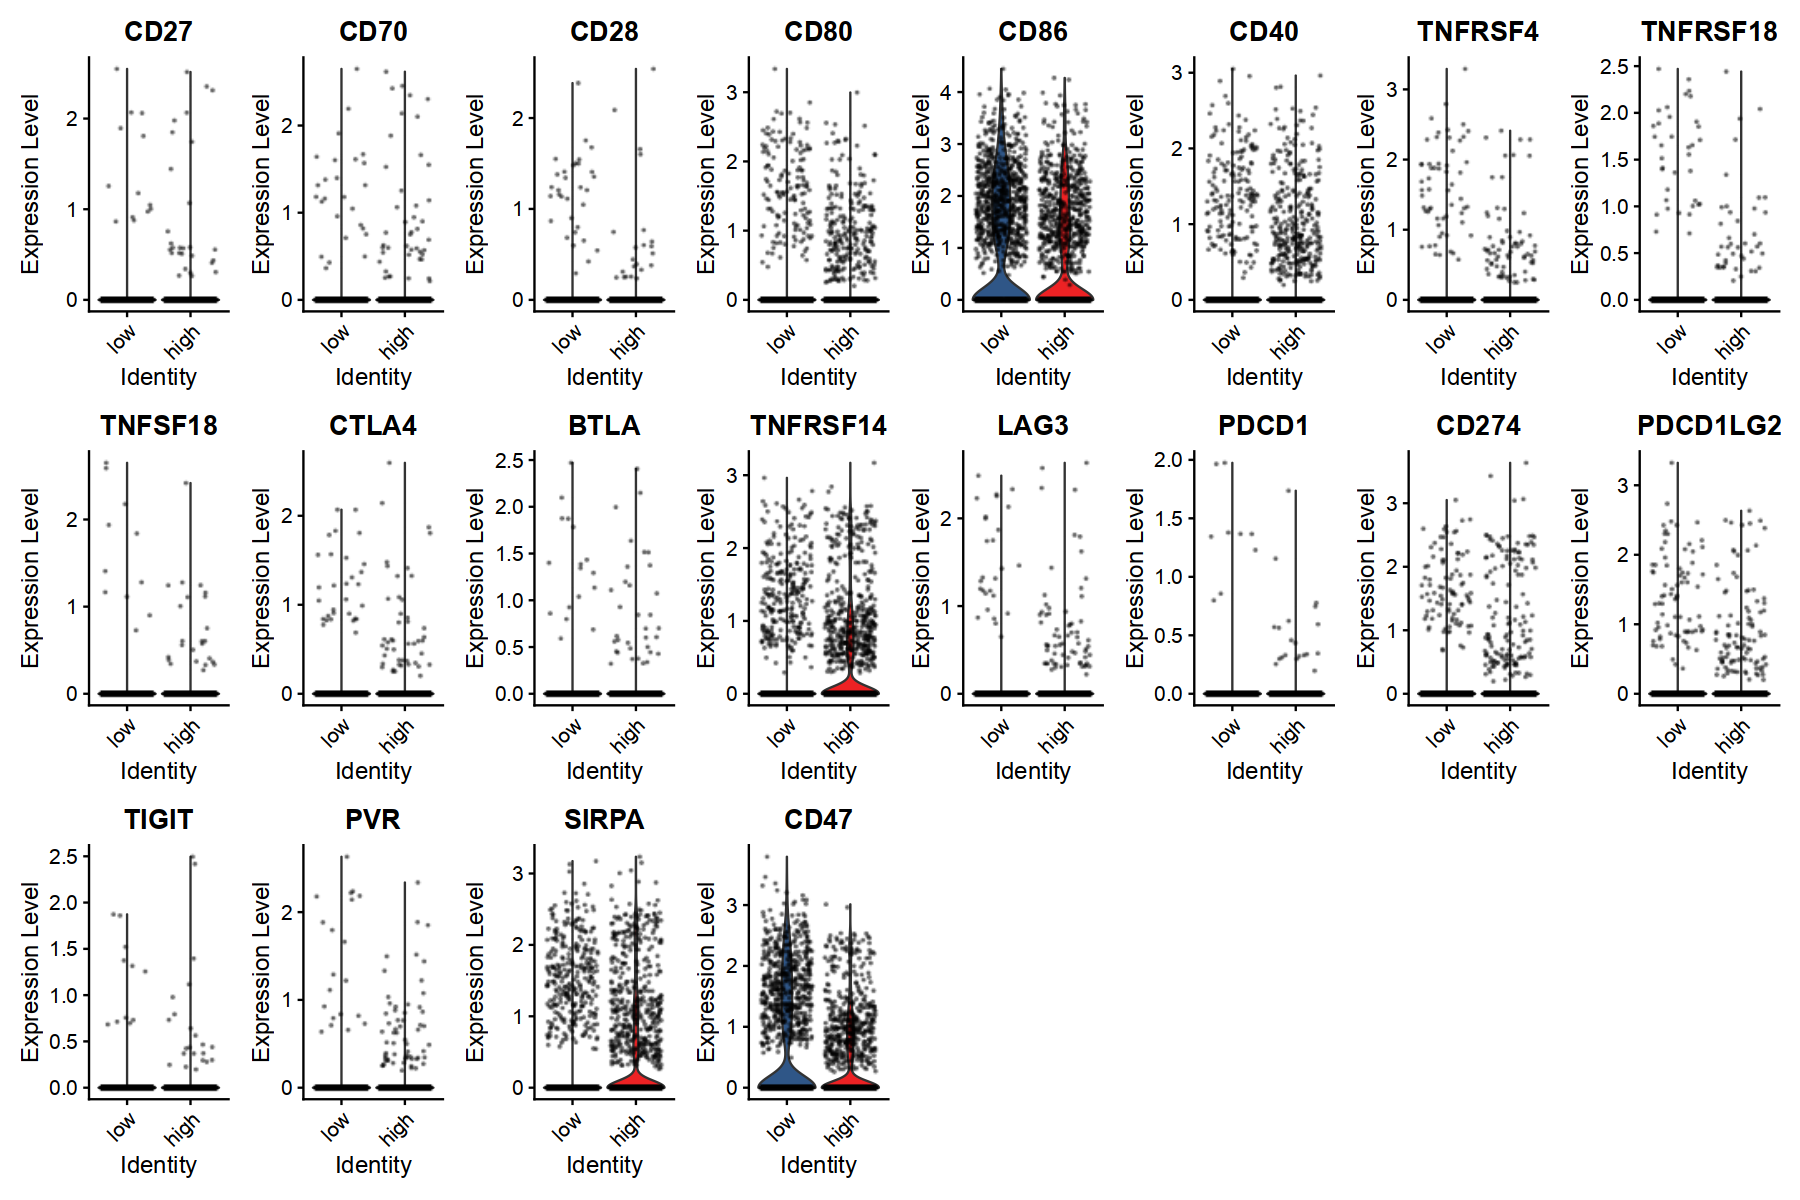

In [57]:
options(repr.plot.width=15,repr.plot.height=10)
p_inh

In [3]:
df <- FetchData(
  GCA_obj_subset_Epi_down,
  vars = c("SIRPA", "CD47", "ident")
)

head(df)

,SIRPA,CD47,ident
,<dbl>,<dbl>,<fct>
AAACGAACAGGCCCTA-1-SC005,0.000000,0.000000,low
ACACTGATCTCGGTCT-1-SC005,0.000000,1.664082,low
ACCTACCGTCCTTAAG-1-SC005,0.000000,0.000000,low
ACGGGTCAGGCATGGT-1-SC005,0.000000,0.000000,low
ACTTTGTAGCAATTAG-1-SC005,1.482966,2.417518,low
AGGGTCCCAGTGGCTC-1-SC005,0.000000,2.325400,low


In [ ]:
df2 <- FetchData(
  GCA_obj_subset_Epi_down,
  vars = c("SIRPA", "CD47", "ident")
)

head(df2)

In [12]:
saveRDS(list(fdr = immunecheckpoint_diff,data = df),
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Figure7e.Rds")

In [58]:
ggsave(filename = "Myeloid_Violin.ic.plot.HvsL.pdf",plot = p_inh,width = 15,height = 10)

In [55]:
save.image('Myeloid_diff.Rds')

In [12]:
low.vs.high.markers   %>% filter(p_val_adj<0.05&abs(avg_log2FC)>0.25) -> low.vs.high.markers2

In [13]:
openxlsx::write.xlsx( low.vs.high.markers2, file = "MacrophageM2_differential.HvsL.xlsx",,rowNames=TRUE)

In [5]:
low.vs.high.markers$label = rownames(low.vs.high.markers)

In [12]:
low.vs.high.markers  %>% mutate(label2 = case_when(p_val_adj<0.05&abs(avg_log2FC)>0.25 ~ label,
                                                          .default = ''))    %>% 
    mutate(label2 = ifelse(label2 %in% c(Inh_immunecheckpoint,Sti_immunecheckpoint), label2, "")) -> low.vs.high.markers

In [36]:
plot_valcano <- function(mydata){
    library(ggpubr)
    library(ggthemes)
    mydata$logP <- -log10(mydata$p_val_adj)
    mydata %>% mutate(group = case_when(p_val_adj<=0.05&avg_log2FC>0.25 ~ 'High', 
                                                  p_val_adj<=0.05&avg_log2FC<(-0.25) ~ "Low",
                                                  p_val_adj>0.05|abs(avg_log2FC)<0.25 ~"NoSig" )) -> mydata
    mytable <- table(mydata$group)
    p_high <- ggscatter(mydata, x = "avg_log2FC", y = "logP", color = "group", label ="label2",
            palette = c("#ED2224" ,"#2f5688", "#BBBBBB"), size = 1, repel = TRUE,## blue, grey,red 
            xlab = "log2FoldChange", ylab = "-log10(Adjust P-value)")+ylim(0,40)+xlim(-7,7)+
    theme_base()+geom_hline(yintercept = -log10(0.05), linetype="dashed")+
    geom_vline(xintercept = c(-0.25,0.25), linetype="dashed")+
    annotate("text", x = 1.5, y = 20, label = mytable[1])+ 
    annotate("text", x = -1.5, y = 20, label = mytable[2])
    return(p_high)
}


In [37]:
p_high <- ggrastr::rasterize(plot_valcano(low.vs.high.markers),dpi=300)

In [13]:
saveRDS(low.vs.high.markers,
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig24a.Rds")

Warning message:
“Removed 16 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 16 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


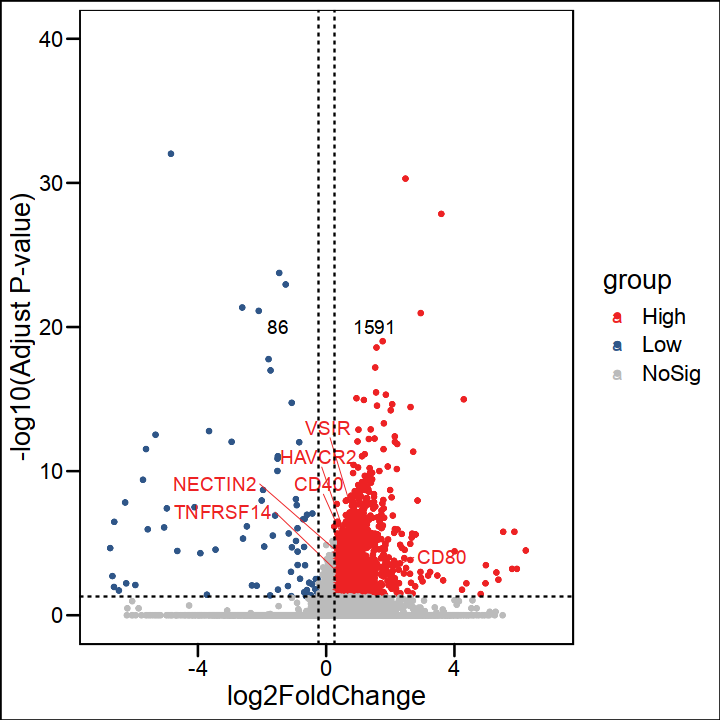

In [38]:
options(repr.plot.width=6,repr.plot.height=6)
p_high

In [39]:
ggsave(filename = "Macrophage_Volcano.plot.HvsL.pdf",plot = p_high,width = 6,height = 6)

Warning message:
“Removed 16 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 16 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


### GSEA

In [21]:
hallmark <- read.gmt("/disk1/pengweixing/esophageal/12.RNAseq/06.GSEA_T_vs_N/h.all.v2023.1.Hs.symbols.gmt")

In [42]:
do_gsea2 <- function(rlt){
  #  genes <- sign(rlt$avg_log2FC)*-log10(rlt$p_val_adj)
    set.seed(123)
    nan_na_index <- which(!is.na(rlt$p_val_adj))
    rlt <- rlt[nan_na_index,]
   # genes <- sign(rlt$avg_log2FC)*-log10(rlt$p_val_adj)
  #  genes <- (rlt$pct.1) *sign(rlt$avg_log2FC)
    genes <- rlt$avg_log2FC
    names(genes) <- rownames(rlt)
    genes <- sort(genes,decreasing = T)
    gsea<-GSEA(genes,TERM2GENE = hallmark,pvalueCutoff = 1,nPermSimple = 10000) 
    y_high <- arrange(as.data.frame(gsea), abs(NES)) %>% filter(p.adjust<=0.05) %>% 
     group_by(sign(NES))
    y_high$Description %>% str_replace('HALLMARK_','')%>% str_to_title() -> y_high$Description
    
    p <- ggplot(y_high, aes(NES, fct_reorder(Description, NES), fill=p.adjust), showCategory=10) + 
     geom_barh(stat='identity') + 
     scale_fill_continuous(low='red', high='blue') + 
     theme_minimal() + ylab(NULL)+theme(axis.text  = element_text(color="black",size=15))
     return(list(gsea = gsea,plot = p))
}

In [43]:
gsea_high_low <- do_gsea2(low.vs.high.markers_coding)

preparing geneSet collections...

GSEA analysis...

leading edge analysis...

done...



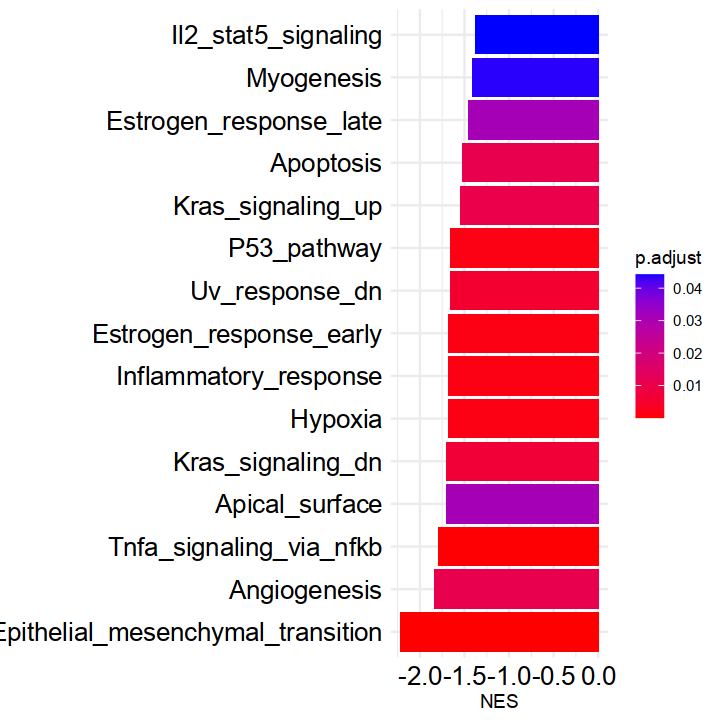

In [44]:
options(repr.plot.height=6,repr.plot.width=6)
gsea_high_low$plot

In [16]:
ggsave(filename = "GSEA.HvsL.pdf",plot = gsea_high_low$plot,width = 6,height = 6)

### GO enrichment

In [26]:
library(org.Hs.eg.db)

In [27]:
DoGO <- function(data){
    gene_id = data$ENTREZID
    data_go <- enrichGO(gene = 
                         gene_id,
                         OrgDb = org.Hs.eg.db,
                         ont = "BP",
                         pAdjustMethod = "BH",
                         qvalueCutoff = 0.05,
                         pvalueCutoff = 0.05,
                         readable = TRUE)
    return(data_go)
}

In [38]:
DoKEGG <- function(data){
    gene_id = data$ENTREZID
    data_kegg <- enrichKEGG(gene        = gene_id,
                         organism     = 'hsa',
                          qvalueCutoff = 0.05,
                         pvalueCutoff = 0.05)
    for(i in 1:nrow(data_kegg@result)){
        data_kegg@result$geneID[i]  %>% str_split('/')  %>% .[[1]] ->a
        a2 <- bitr(a, fromType="ENTREZID", toType="SYMBOL", OrgDb="org.Hs.eg.db")
        paste0(a2$SYMBOL ,collapse = '/') -> a3
        data_kegg@result$geneID[i] <- a3
}
    return(data_kegg)
}

In [29]:
low.vs.high.markers_coding  %>% filter(p_val_adj<0.05&avg_log2FC>0.25&pct.1>0.1)  %>%  rownames() -> high_geneid

In [30]:
low.vs.high.markers_coding  %>% filter(p_val_adj<0.05&avg_log2FC<(-0.25)&pct.2>0.1)  %>%  rownames() -> low_geneid

In [31]:
length(high_geneid);length(low_geneid)

[1] 1529

[1] 78

In [32]:
high_geneid2 = bitr(high_geneid, fromType="ALIAS", toType="ENTREZID", OrgDb="org.Hs.eg.db")

'select()' returned 1:many mapping between keys and columns

Warning message in bitr(high_geneid, fromType = "ALIAS", toType = "ENTREZID", OrgDb = "org.Hs.eg.db"):
“0.39% of input gene IDs are fail to map...”


In [33]:
low_geneid2 = bitr(low_geneid, fromType="ALIAS", toType="ENTREZID", OrgDb="org.Hs.eg.db")

'select()' returned 1:many mapping between keys and columns



In [34]:
high_go <- DoGO(high_geneid2)

In [35]:
low_go <- DoGO(low_geneid2)

In [ ]:
high_kegg <- DoKEGG(high_geneid2)
low_kegg <- DoKEGG(low_geneid2)

In [16]:
options(repr.plot.height=8,repr.plot.width=8)
p_go_high <- dotplot(high_go, showCategory=20,  label_format = 60) + ggtitle("dotplot for High")

In [17]:
options(repr.plot.height=8,repr.plot.width=7)
p_go_low <- dotplot(low_go, showCategory=20,  label_format = 60) + ggtitle("dotplot for Low")

In [18]:
options(repr.plot.height=8,repr.plot.width=6)
p_kegg_high <- dotplot(high_kegg, showCategory=20,  label_format = 60) + ggtitle("dotplot for High")

In [19]:
options(repr.plot.height=8,repr.plot.width=6)
p_kegg_low <- dotplot(low_kegg, showCategory=20,  label_format = 60) + ggtitle("dotplot for Low")

In [22]:
library(ggpubr)

In [31]:
p_all <- ggarrange(p_go_low,p_go_high,p_kegg_low,p_kegg_high,
          labels = c('GO_Low','GO_High','KEGG_Low','KEGG_High'))

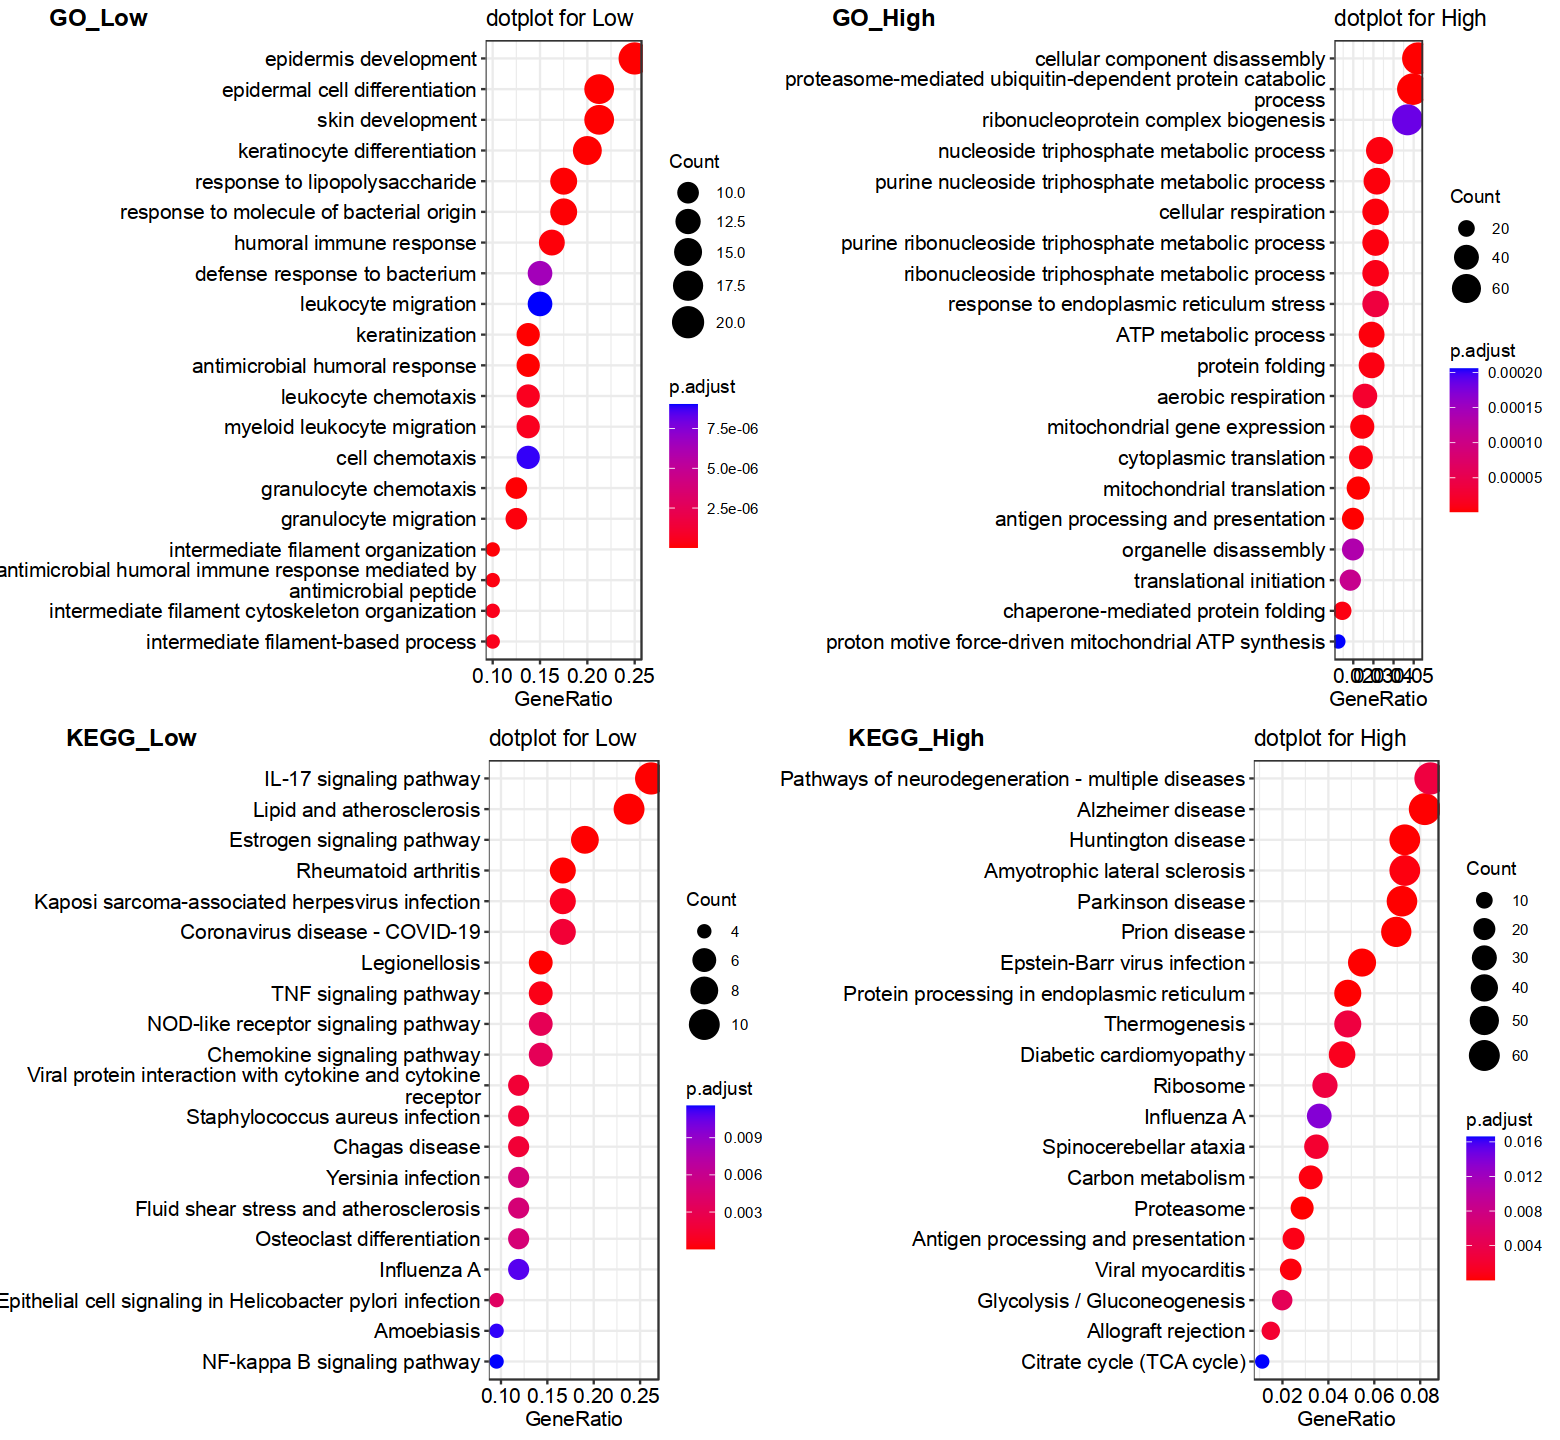

In [35]:
options(repr.plot.height=12,repr.plot.width=13)
p_all

In [36]:
ggsave(filename = "MacrophageM2_GO_KEGG.pdf",plot =p_all,width = 13,height = 12)

In [56]:
openxlsx::write.xlsx(list(High = as.data.frame(high_kegg),Low = as.data.frame(low_kegg)),file = "MacroM2.KEGG.xlsx")
openxlsx::write.xlsx(list(High = as.data.frame(high_go),Low = as.data.frame(low_go)),file = "MacroM2.GO.xlsx")

In [42]:
get_plot <- function(C2_go,C3_go){
    C2_go %>% as.data.frame()  -> C2_temp
    C3_go %>% as.data.frame() -> C3_temp
    C2_temp  %>% dplyr::select(Description,GeneRatio,p.adjust,Count) %>% 
    mutate(group = "High") -> C2_temp2
    C3_temp  %>% dplyr::select(Description,GeneRatio,p.adjust,Count)  %>% 
        mutate(Description=Description,group = "Low") -> C3_temp2
    if(nrow(C2_temp2)>10){
        C2_temp2 = C2_temp2[1:10,]
    }else if(nrow(C2_temp2)>0){
        C2_temp2 = C2_temp2[1:nrow(C2_temp2),]
    }else{
        C2_temp2 = C2_temp
    }
        
    if(nrow(C3_temp2)>10){
        C3_temp2 = C3_temp2[1:10,]
    }else if(nrow(C3_temp2)>0){
        C3_temp2 = C3_temp2[1:nrow(C3_temp2),]
    }else{
        C3_temp2 = C3_temp
    }
    
    rbind(C2_temp2,C3_temp2) -> C2_C3_comb
        
   # C2_C3_comb %>% mutate(GeneRatio2 = sapply(GeneRatio,function(x) eval(parse(text = x))))  -> C2_C3_comb
  #  C2_C3_comb  %>% mutate(GeneRatio2 = ifelse(group=="C2",-GeneRatio2,GeneRatio2)) -> C2_C3_comb
  #  C2_C3_comb$Description  <- factor(C2_C3_comb$Description,levels = unique(C2_C3_comb  %>% arrange((Count)) %>% .[,1]))
  #  ceiling(max(abs(C2_C3_comb$GeneRatio2))  * 100) / 100 -> xrange
    
    C2_C3_comb  %>% mutate(GeneRatio2 = ifelse(group=="High",'High','Low')) -> C2_C3_comb
    C2_C3_comb$Description  <- factor(C2_C3_comb$Description,levels = unique(C2_C3_comb  %>% arrange((Count)) %>% .[,1]))

    p <- ggplot(data = C2_C3_comb) + geom_point(aes(x=GeneRatio2,y = Description,size=Count,color=p.adjust)) + 
        theme(panel.background = element_rect(fill="NA"),
              panel.grid.major.y = element_line(color='gray',linetype='dashed'),
              axis.text = element_text(color = 'black'),
             panel.border = element_rect(fill=NA,color='black'),) + geom_vline(xintercept = 0) +
           # xlim(-xrange,xrange)+
            ylab('')+xlab('') + theme(axis.text.y = element_text(size=11)) +
            scale_colour_gradientn(colors = (colorRampPalette(brewer.pal(9, "RdYlBu"))(100))[0:80])
          #  ggtitle(label =mytype )
    return(p)
}

In [43]:
library(RColorBrewer )

In [44]:
p_GO <- get_plot(high_go,low_go)

In [45]:
p_KEGG <- get_plot(high_kegg,low_kegg)

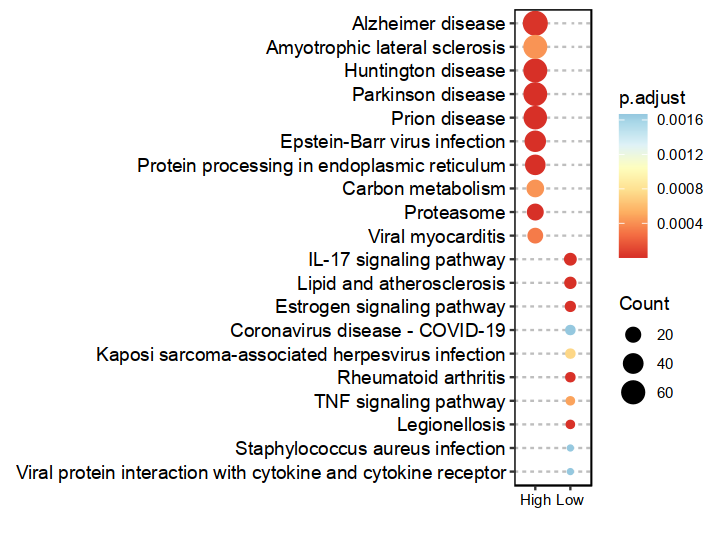

In [52]:
options(repr.plot.height=4.5,repr.plot.width=6)
p_KEGG

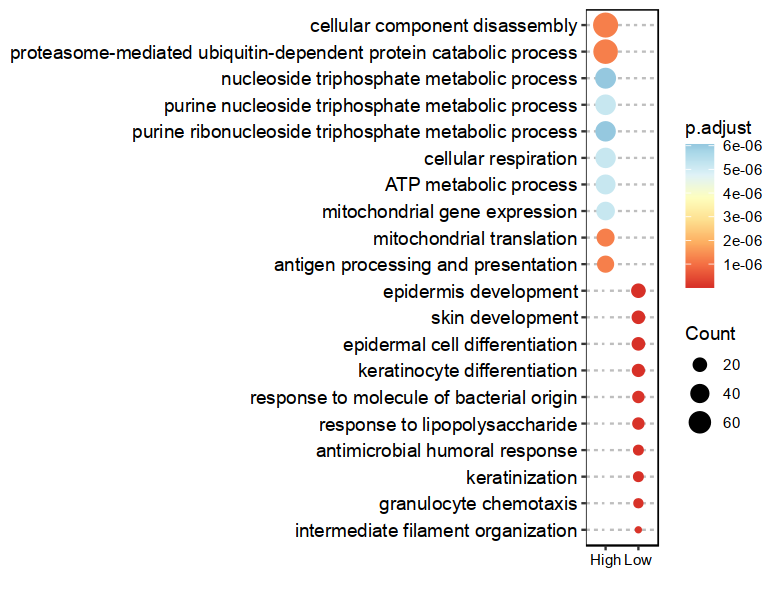

In [53]:
options(repr.plot.height=5,repr.plot.width=6.5)
p_GO

In [54]:
ggsave(filename ="M2_HighvsLow_KEGGannotation.pdf",plot = p_KEGG,height = 4.5, width = 6)
ggsave(filename ="M2_HighvsLow_GOannotation.pdf",plot = p_GO,height = 5, width = 6.5)

### show some genes

In [10]:
Sti_immunecheckpoint <- c("CD27","CD70",## stimulatory, T cell receptor, APC ligand
                      "CD28","CD80","CD86",## stimulatory, CD4+ T cell receptor, APC ligand *2       
                      "CD40","CD40LG",## stimulatory,  CD4+ T cell ligand,APC cell receptor
                      "IL2RB","IL2",## stimulatory, receptor, CD4+ Tcell ligand
                      "TNFRSF9","CDC37L1",## stimulatory, Tcell receptor, APC ligand
                      "TNFRSF4","TNFSF4",## stimulatory, (OX40:OX40L) Tregs Receptor, APC ligand
                      "TNFRSF18","TNFSF18",## stimulatory (aka,GITR), CD8+ T cell Receptor, APC ligand 
                      "ICOS","ICOSLG",## stimulatory, CD4+ T cell Receptor, APC ligand
                        "TMIGD2","HHLA2"### Receptor , APC
                      )

In [11]:
Inh_immunecheckpoint <- c("CTLA4","CD80","CD86",## Inhibitory,Tregs receptor, APC ligand *2
                      "ADORA2A","ADORA2B",##Inhibitory , Tcell receptor, ligand: adenosine
                      "BTLA","TNFRSF14", ##Inhibitory, aka TNFRSF14 HVEM, Tcell receptor, APC ligand
                      "LAG3","FGL1", ###Inhibitory, Tcell receptor,APC ligand.
                      "PDCD1","CD274","PDCD1LG2",##Inhibitory Tcell receptor, APC ligand
                      "HAVCR2","HMGB1","LGALS9","CEACAM1",##aka,TIM-3,Inhibitory, Tcell receptor, APC ligand *3
                      "VSIR","IGSF11",##Inhibitory, Tcell receptor, APC ligand
                      "SIGLEC7",##Inhibitory, Tcell receptor , ligand: sugar
                      "TIGIT","PVR","NECTIN2",##Inhibitory, Tcell ligand, APC recetpor
                      "SIRPA","CD47" ##Inhibitory, immune ligand, APC recetpor
                      )

In [41]:
Idents(GCA_obj_subset_Epi_down) <- "group"

In [48]:
GCA_obj_subset_Epi_down[['RNA']]

Assay (v5) data with 36601 features for 482 cells
Top 10 variable features:
 IGLC1, IGHM, LIPF, IGHG2, LUM, IGLV1-44, IGLV2-14, RGS5, IGHA2, CXCL10 
Layers:
 data, counts, scale.data 

In [67]:
options(repr.plot.width=3,repr.plot.height=5)
p_sti <- VlnPlot(GCA_obj_subset_Epi_down, 
        features = Sti_immunecheckpoint, ncol = 4,
        idents = c("high","low"),pt.size = 0.1,raster=TRUE,alpha = 0.5) 

Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of TMIGD2.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of HHLA2.”


In [ ]:
options(repr.plot.width=13,repr.plot.height=20)
p_sti

In [112]:
ggsave(filename = "MacroM2_Stimulatory_immune_voillin.pdf",plot = p_sti,width = 13,height = 20)

In [106]:
options(repr.plot.width=3,repr.plot.height=5)
p_inh <- VlnPlot(GCA_obj_subset_Epi_down, 
        features = Inh_immunecheckpoint, ncol = 5,
        idents = c("high","low"),pt.size = 0.1,raster=TRUE,alpha = 0.5) 

Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of IGSF11.”


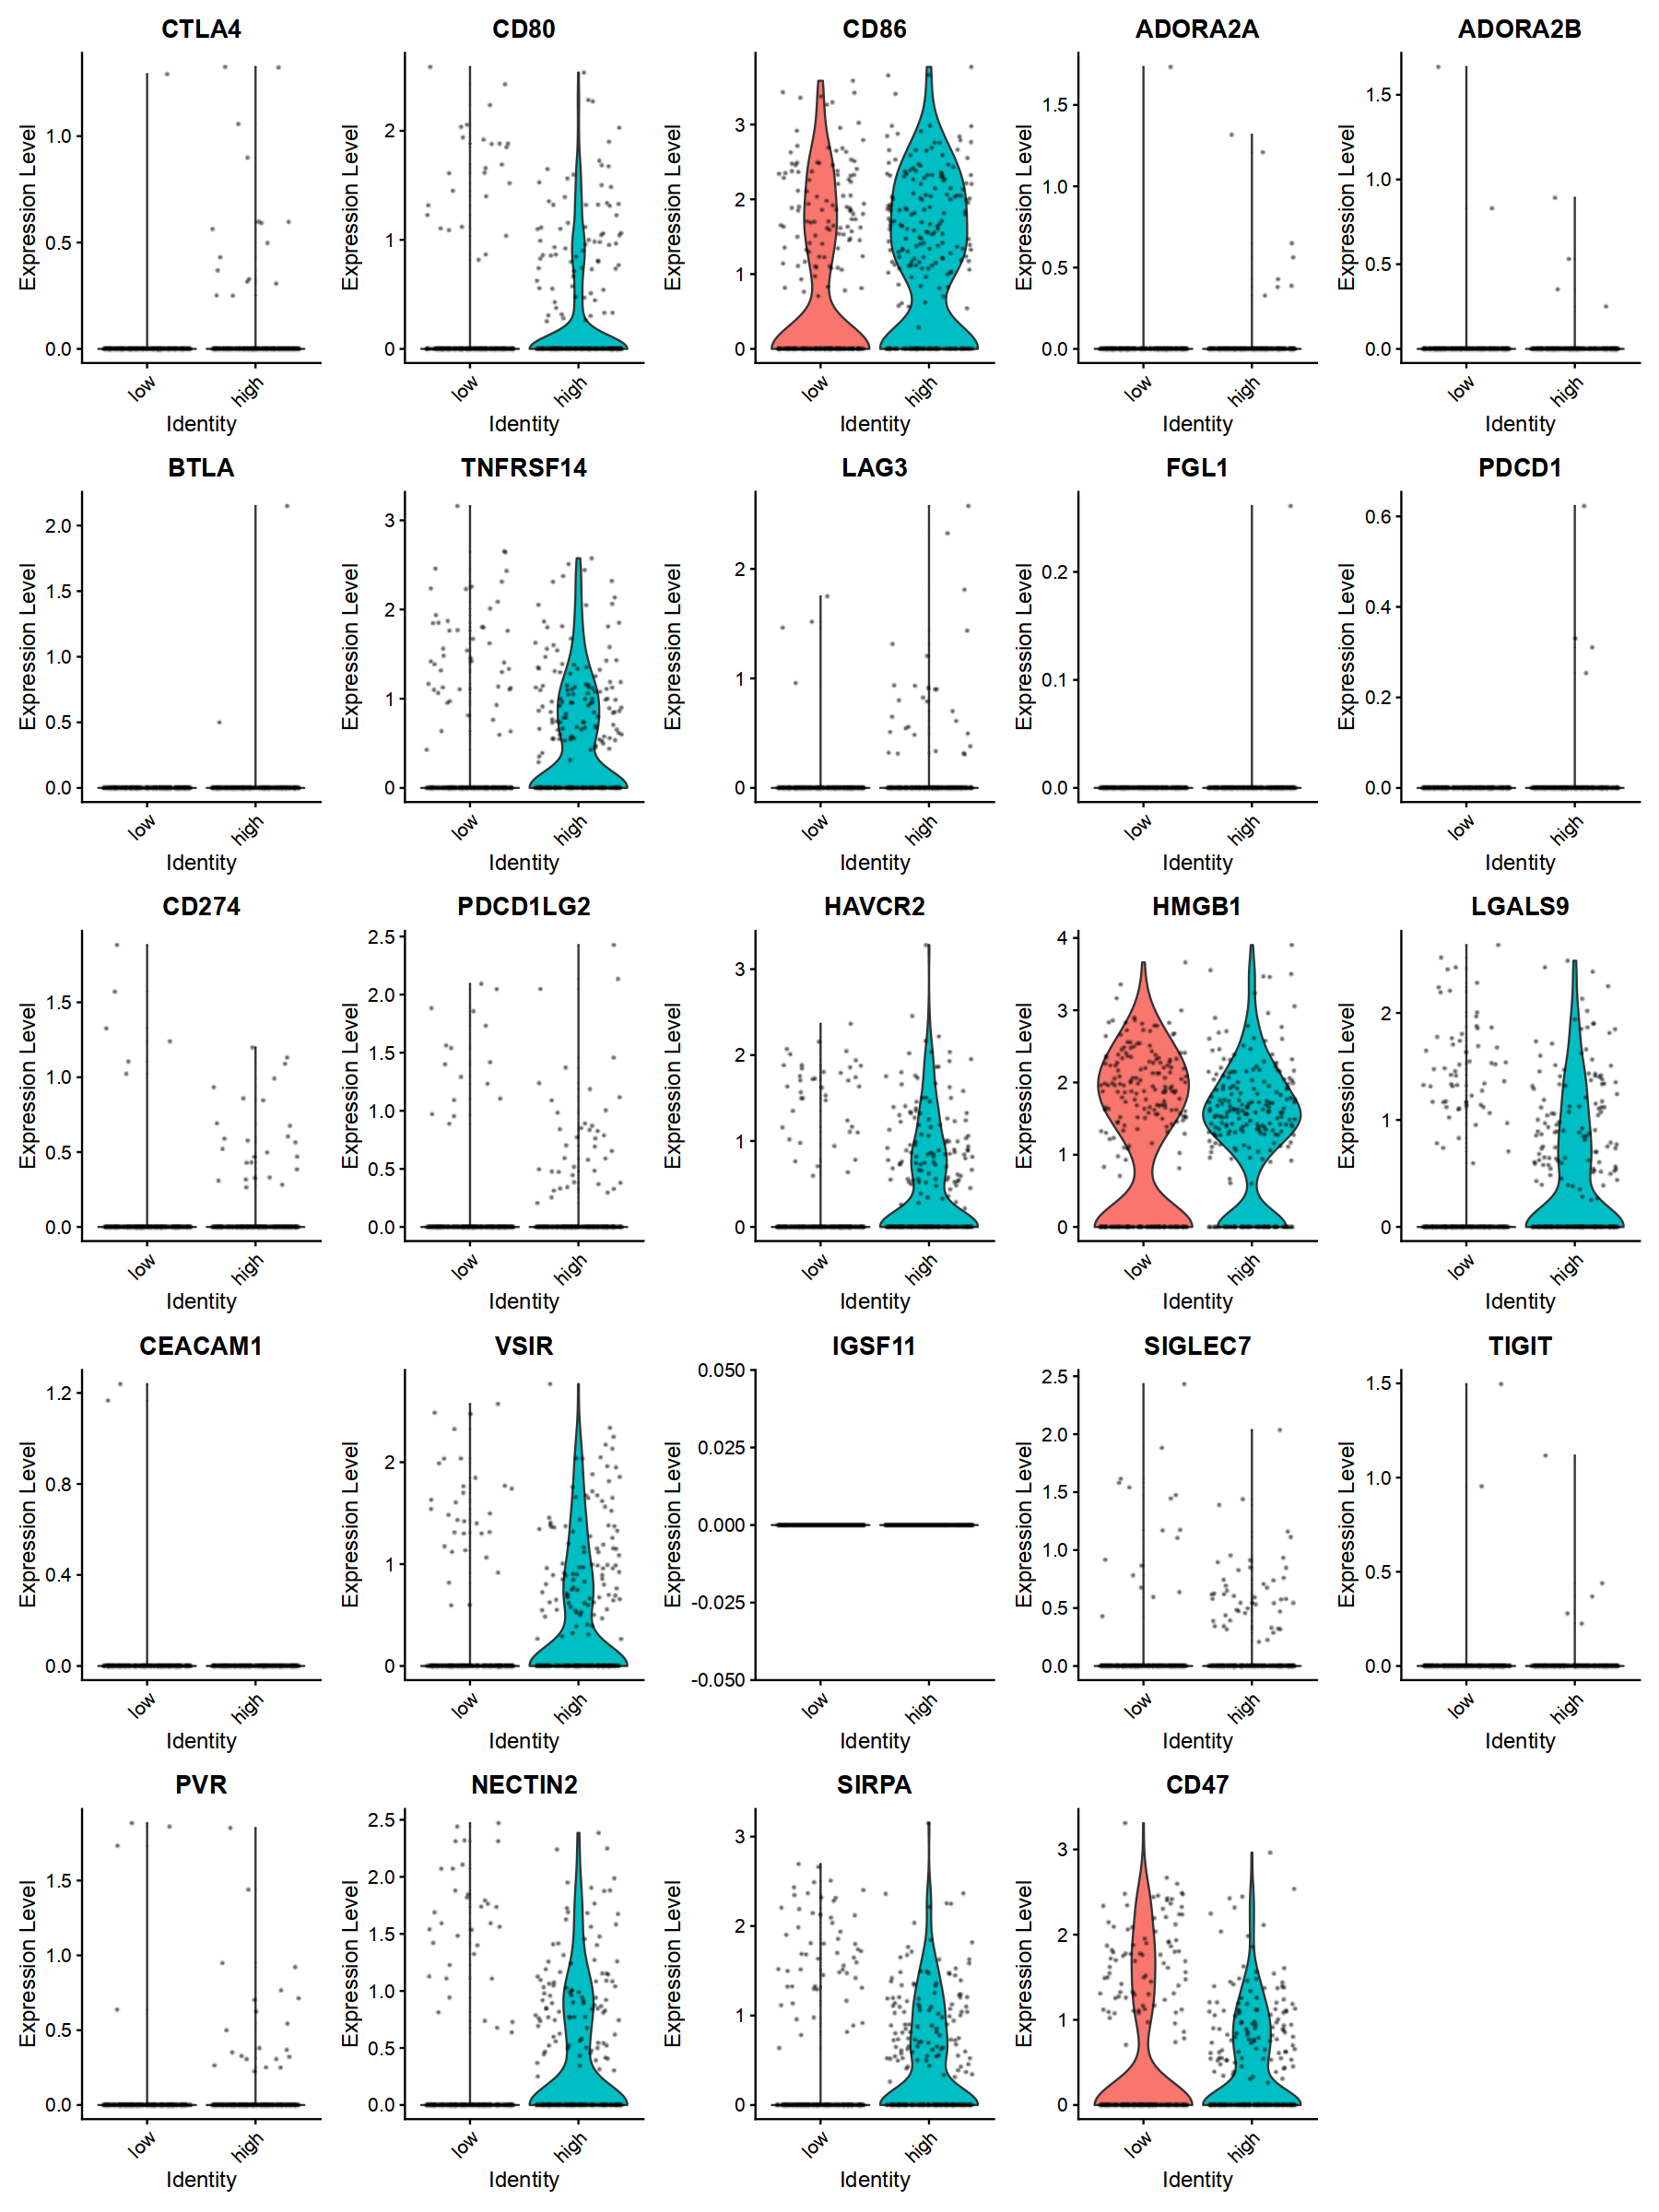

In [109]:
options(repr.plot.width=15,repr.plot.height=20)
p_inh

In [111]:
ggsave(filename = "MacroM2_Inhibitory_immune_voillin.pdf",plot = p_inh,width = 15,height = 20)

In [15]:
save.image('macrophageMyloied_diff.Rds')